# Sentiment Analysis & Prediction

In [170]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from wordcloud import WordCloud
from sklearn import model_selection, preprocessing, linear_model, naive_bayes
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix, ConfusionMatrixDisplay
from sklearn import ensemble
import xgboost

import pickle

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from warnings import filterwarnings
filterwarnings('ignore')

## First Look

In [171]:
data = pd.read_excel("../data/TurkishTweets.xlsx")

In [172]:
data.head()

,Tweet,Etiket
0,Allah'ım çıldıracağım. Yemin ederim çıldıracağ...,kızgın
1,site ne zaman çalıştıda ürün stokları bitti di...,kızgın
2,Sebebi neydi ki diye bağıracağım şimdi az kaldı,kızgın
3,Black friday ne amk bu yıl çıkardınız bu bokud...,kızgın
4,kısa kısa cevaplar vericeksen niye yazıyorsun ...,kızgın


In [173]:
data["Etiket"].value_counts()

Etiket
kızgın     800
korku      800
mutlu      800
surpriz    800
üzgün      800
Name: count, dtype: int64

In [174]:
data.count()

Tweet     3999
Etiket    4000
dtype: int64

In [175]:
df = pd.DataFrame()
df["text"] = data["Tweet"]
df["label"] = data["Etiket"]

In [176]:
df.head()

,text,label
0,Allah'ım çıldıracağım. Yemin ederim çıldıracağ...,kızgın
1,site ne zaman çalıştıda ürün stokları bitti di...,kızgın
2,Sebebi neydi ki diye bağıracağım şimdi az kaldı,kızgın
3,Black friday ne amk bu yıl çıkardınız bu bokud...,kızgın
4,kısa kısa cevaplar vericeksen niye yazıyorsun ...,kızgın


## Text Preprocessing

In [177]:
df['text'] = df['text'].fillna("Bugün kendimi gerçekten kötü hissediyorum, hiçbir şey iyi gitmiyor gibi.")

In [178]:
df['text'] = df['text'].apply(lambda x: x.lower())

df['text'] = df['text'].str.replace(r'[^a-zA-ZçğıöşüÇĞİÖŞÜ\s]', '', regex=True)

df["text"] = df["text"].str.replace(r'\d','',regex=True)


In [179]:
turkish_stopwords = [
    "ama", "amma", "anca", "ancak", "belki", "çünkü", "dahi", "eğer", "emme","fakat", "gah", "gerek", "hakeza", "halbuki", "hatta", "hele", "hem", "hoş", 
    "ile", "imdi", "ister", "kah", "keşke", "keza", "kezalik", "kim", "lakin","madem", "mademki", "mamafih", "meğer", "meğerki", "meğerse", "netekim", "neyse", 
    "nitekim", "oysa", "oysaki", "şayet", "velev", "velhasıl", "velhasılıkelam", "veya","veyahut", "yahut", "yalnız", "yani", "yok", "yoksa", "zira", "acaba", "acep", 
    "açıkça", "açıkçası", "adamakıllı", "adeta", "bazen", "bazı", "bilcümle", "binaen","binaenaleyh", "bir", "biraz", "birazdan", "birden", "birdenbire", "birice", 
    "birlikte", "bitevi", "biteviye", "bittabi", "bizatihi", "bizce", "bizcileyin","bizden", "bizzat", "boşuna", "böyle", "böylece", "böylelikle", "böylemesine", 
    "böylesine", "buracıkta", "burada", "buradan", "büsbütün", "çabuk", "çabukça","çeşitli", "çoğu", "çoğun", "çoğunca", "çoğunlukla", "çok", "çokça", "çokluk", 
    "çoklukla", "cuk", "daha", "dahil", "dahilen", "daima", "demin", "demincek","deminden", "derakap", "derhal", "derken", "diye", "elbet", "elbette", "enikonu", 
    "epey", "epeyce", "epeyi", "esasen", "esnasında", "etraflı", "etraflıca","evleviyetle", "evvel", "evvela", "evvelce", "evvelden", "evvelemirde", "evveli", 
    "gayet", "gayetle", "gayri", "gayrı", "geçende", "geçenlerde", "gene", "gerçi","gibi", "gibilerden", "gibisinden", "gine", "halen", "halihazırda", "haliyle", 
    "handiyse", "hani", "hasılı", "hulasaten", "iken", "illa", "illaki", "itibarıyla","iyice", "iyicene", "kala", "kez", "kısaca", "külliyen", "lütfen", "nasıl", 
    "nasılsa", "nazaran", "neden", "nedeniyle", "nedense", "nerde", "nerden", "nerede","nereden", "neredeyse", "nereye", "neye", "neyi", "nice", "niçin", "nihayet", 
    "nihayetinde", "niye", "oldu", "oldukça", "olur", "onca", "önce", "önceden","önceleri", "öncelikle", "onculayın", "ondan", "oracık", "oracıkta", "orada", 
    "oradan", "oranca", "oranla", "oraya", "öyle", "öylece", "öylelikle", "öylemesine","pek", "pekala", "pekçe", "peki", "peyderpey", "sadece", "sahi", "sahiden", 
    "sanki", "sonra", "sonradan", "sonraları", "sonunda", "şöyle", "şuncacık","şuracıkta", "tabii", "tam", "tamam", "tamamen", "tamamıyla", "tek", "vasıtasıyla", 
    "yakinen", "yakında", "yakından", "yakınlarda", "yalnız", "yalnızca", "yeniden","yenilerde", "yine", "yok", "yoluyla", "yüzünden", "zaten", "zati", "ait", "bari", 
    "beri", "bile", "değin", "dek", "denli", "doğru", "dolayı", "dolayısıyla","gelgelelim", "gibi", "gırla", "göre", "hasebiyle", "için", "ila", "ile", "ilen", 
    "indinde", "inen", "kadar", "kaffesi", "karşın", "kelli", "Leh", "maada", "mebni","naşi", "rağmen", "üzere", "zarfında", "öbür", "bana", "başkası", "ben", "beriki", 
    "birbiri", "birçoğu", "biri", "birileri", "birisi", "birkaçı", "biz", "bizimki","buna", "bunda", "bundan", "bunlar", "bunu", "bunun", "burası", "çoğu", "çokları", 
    "çoklarınca", "cümlesi", "değil", "diğeri", "filanca", "hangisi", "hepsi","hiçbiri", "iş", "kaçı", "kaynak", "kendi", "kim", "kimi", "kimisi", "kimse", 
    "kimse", "kimsecik", "kimsecikler", "nere", "neresi", "öbürkü", "öbürü", "ona","onda", "ondan", "onlar", "onu", "onun", "öteki", "ötekisi", "öz", "sana", "sen",
    "siz", "şuna", "şunda", "şundan", "şunlar", "şunu", "şunun", "şura", "şuracık","şurası"
]

In [180]:
sw = turkish_stopwords
df['text'] = df['text'].apply(lambda x: " ".join(x for x in x.split() if x not in sw))

In [181]:
df.head()

,text,label
0,allahım çıldıracağım yemin ederim çıldıracağım...,kızgın
1,site ne zaman çalıştıda ürün stokları bitti di...,kızgın
2,sebebi neydi ki bağıracağım şimdi az kaldı,kızgın
3,black friday ne amk bu yıl çıkardınız bu bokud...,kızgın
4,kısa kısa cevaplar vericeksen yazıyorsun geriz...,kızgın


## Train-Test Split & Label Encoder

In [182]:
train_X,test_X,train_y,test_y = model_selection.train_test_split(df["text"],
                                                                   df["label"], 
                                                                    random_state = 1)

In [183]:
encoder = preprocessing.LabelEncoder()

In [184]:
encoder.fit(train_y)
train_y  = encoder.transform(train_y)
test_y  = encoder.transform(test_y)

In [185]:
encoder.classes_

array(['korku', 'kızgın', 'mutlu', 'surpriz', 'üzgün'], dtype=object)

In [186]:
print(train_y[0:5])
print(test_y[0:5])

[3 0 1 1 3]
[1 0 1 2 0]


## EDA

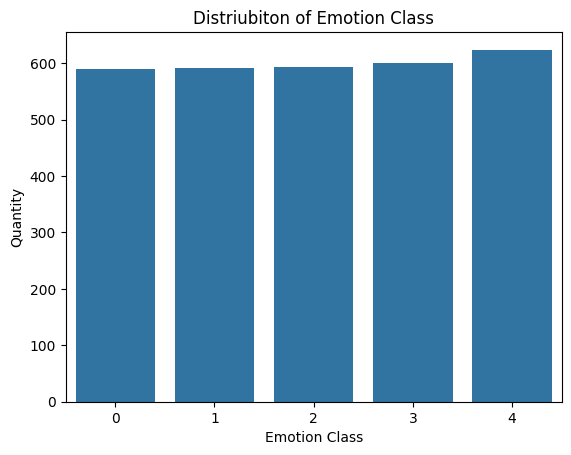

In [187]:
sns.countplot(x=train_y)
plt.title("Distriubiton of Emotion Class")
plt.xlabel("Emotion Class")
plt.ylabel("Quantity")
plt.show()

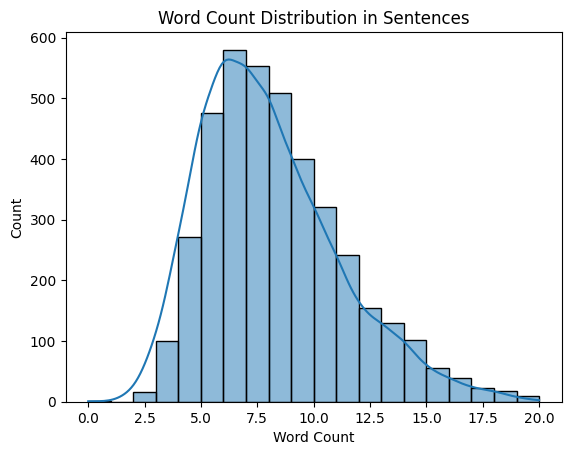

In [188]:
df['text_len'] = df['text'].apply(lambda x: len(x.split()))
sns.histplot(df['text_len'], bins=20, kde=True)
plt.title("Word Count Distribution in Sentences")
plt.xlabel("Word Count")
plt.show()

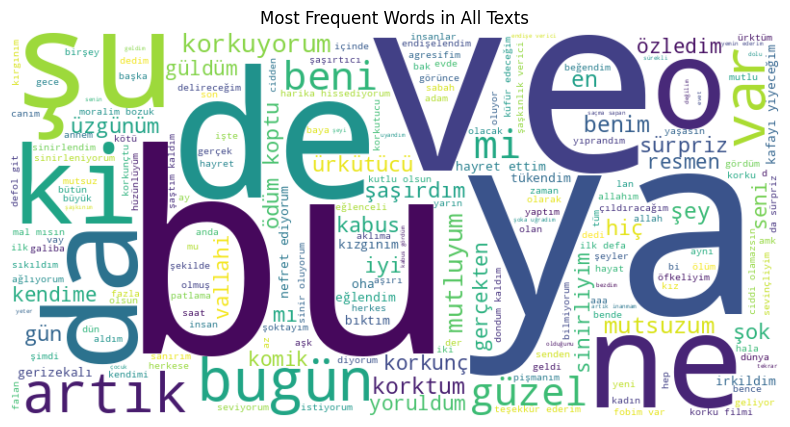

In [189]:
all_text = " ".join(df["text"])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in All Texts")
plt.show()


## Feature Engineering

### Count Vector

In [190]:
vectorizer = CountVectorizer()
vectorizer.fit(train_X)

CountVectorizer()

In [191]:
X_train_count_vectorizer = vectorizer.transform(train_X)
X_test_count_vectorizer = vectorizer.transform(test_X)

In [192]:
vectorizer.get_feature_names_out()[0:5]

array(['aaa', 'abartma', 'abartmayın', 'abartı', 'abd'], dtype=object)

In [193]:
X_train_count_vectorizer.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

### TF-IDF

#### WordLevel

In [194]:
tf_idf_word_vectorizer = TfidfVectorizer()
tf_idf_word_vectorizer.fit(train_X)

TfidfVectorizer()

In [195]:
X_train_tf_idf_word_vectorizer = tf_idf_word_vectorizer.transform(train_X)
X_test_tf_idf_word_vectorizer = tf_idf_word_vectorizer.transform(test_X)

In [196]:
tf_idf_word_vectorizer.get_feature_names_out()[0:5]

array(['aaa', 'abartma', 'abartmayın', 'abartı', 'abd'], dtype=object)

#### N-Gram Level

In [197]:
tf_idf_ngram_vectorizer = TfidfVectorizer(ngram_range=(2,3))
tf_idf_ngram_vectorizer.fit(train_X)

TfidfVectorizer(ngram_range=(2, 3))

In [198]:
X_train_tf_idf_ngram_vectorizer = tf_idf_ngram_vectorizer.transform(train_X)
X_test_tf_idf_ngram_vectorizer = tf_idf_ngram_vectorizer.transform(test_X)

In [199]:
tf_idf_ngram_vectorizer.get_feature_names_out()[0:5]

array(['aaa altı', 'aaa altı üstü', 'aaa annen', 'aaa annen mi', 'aaa bu'],
      dtype=object)

#### Characters Level

In [200]:
tf_idf_chars_vectorizer = TfidfVectorizer(analyzer='char',ngram_range=(2,3))
tf_idf_chars_vectorizer.fit(train_X)

TfidfVectorizer(analyzer='char', ngram_range=(2, 3))

In [201]:
X_train_tf_idf_chars_vectorizer = tf_idf_chars_vectorizer.transform(train_X)
X_test_tf_idf_chars_vectorizer = tf_idf_chars_vectorizer.transform(test_X)

In [202]:
tf_idf_chars_vectorizer.get_feature_names_out()[0:5]

array([' a', ' a ', ' aa', ' ab', ' ac'], dtype=object)

## Machine Learning

### Logistic Regression 

#### Count Vectorizer

In [203]:
log_model = linear_model.LogisticRegression(max_iter=1000, multi_class='multinomial')
log_model.fit(X_train_count_vectorizer, train_y) 
preds = log_model.predict(X_test_count_vectorizer)

print("Logistic Regression Accuracy:", accuracy_score(test_y, preds))
print(classification_report(test_y, preds))

Logistic Regression Accuracy: 0.974
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       210
           1       0.99      0.97      0.98       208
           2       0.95      0.96      0.96       207
           3       1.00      0.98      0.99       199
           4       0.93      0.98      0.95       176

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



#### Word Level

In [204]:
log_model = linear_model.LogisticRegression(max_iter=1000, multi_class='multinomial')
log_model.fit(X_train_tf_idf_word_vectorizer, train_y) 
preds = log_model.predict(X_test_tf_idf_word_vectorizer)

print("Logistic Regression Accuracy:", accuracy_score(test_y, preds))
print(classification_report(test_y, preds))

Logistic Regression Accuracy: 0.974
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       210
           1       0.98      0.97      0.97       208
           2       0.96      0.97      0.97       207
           3       0.98      0.98      0.98       199
           4       0.95      0.98      0.96       176

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



#### N-Gram

In [205]:
log_model = linear_model.LogisticRegression(max_iter=1000, multi_class='multinomial')
log_model.fit(X_train_tf_idf_ngram_vectorizer, train_y) 
preds = log_model.predict(X_test_tf_idf_ngram_vectorizer)

print("Logistic Regression Accuracy:", accuracy_score(test_y, preds))
print(classification_report(test_y, preds))

Logistic Regression Accuracy: 0.621
              precision    recall  f1-score   support

           0       0.88      0.47      0.61       210
           1       0.85      0.67      0.75       208
           2       0.79      0.51      0.62       207
           3       0.90      0.60      0.72       199
           4       0.35      0.89      0.50       176

    accuracy                           0.62      1000
   macro avg       0.75      0.63      0.64      1000
weighted avg       0.76      0.62      0.64      1000



#### Characters

In [206]:
log_model = linear_model.LogisticRegression(max_iter=1000, multi_class='multinomial')
log_model.fit(X_train_tf_idf_chars_vectorizer, train_y) 
preds = log_model.predict(X_test_tf_idf_chars_vectorizer)

print("Logistic Regression Accuracy:", accuracy_score(test_y, preds))
print(classification_report(test_y, preds))

Logistic Regression Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       210
           1       0.95      0.96      0.95       208
           2       0.93      0.92      0.93       207
           3       0.95      0.94      0.95       199
           4       0.93      0.95      0.94       176

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



### Naive Bayes

#### Count Vectorizer

In [207]:
naive_model = naive_bayes.MultinomialNB()
naive_model.fit(X_train_count_vectorizer, train_y) 
preds = naive_model.predict(X_test_count_vectorizer)

print("Naive Bayes Accuracy:", accuracy_score(test_y, preds))
print(classification_report(test_y, preds))

Naive Bayes Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       210
           1       0.95      0.95      0.95       208
           2       0.94      0.94      0.94       207
           3       0.92      0.97      0.94       199
           4       0.97      0.91      0.94       176

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



#### Word Level

In [208]:
naive_model = naive_bayes.MultinomialNB()
naive_model.fit(X_train_tf_idf_word_vectorizer, train_y) 
preds = naive_model.predict(X_test_tf_idf_word_vectorizer)

print("Naive Bayes Accuracy:", accuracy_score(test_y, preds))
print(classification_report(test_y, preds))

Naive Bayes Accuracy: 0.956
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       210
           1       0.96      0.96      0.96       208
           2       0.94      0.94      0.94       207
           3       0.93      0.97      0.95       199
           4       0.97      0.94      0.95       176

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



#### N-Gram

In [209]:
naive_model = naive_bayes.MultinomialNB()
naive_model.fit(X_train_tf_idf_ngram_vectorizer, train_y) 
preds = naive_model.predict(X_test_tf_idf_ngram_vectorizer)

print("Naive Bayes Accuracy:", accuracy_score(test_y, preds))
print(classification_report(test_y, preds))

Naive Bayes Accuracy: 0.625
              precision    recall  f1-score   support

           0       0.86      0.48      0.62       210
           1       0.86      0.67      0.76       208
           2       0.84      0.50      0.63       207
           3       0.87      0.62      0.73       199
           4       0.34      0.89      0.50       176

    accuracy                           0.62      1000
   macro avg       0.76      0.63      0.64      1000
weighted avg       0.77      0.62      0.65      1000



#### Characters

In [210]:
naive_model = naive_bayes.MultinomialNB()
naive_model.fit(X_train_tf_idf_chars_vectorizer, train_y) 
preds = naive_model.predict(X_test_tf_idf_chars_vectorizer)

print("Naive Bayes Accuracy:", accuracy_score(test_y, preds))
print(classification_report(test_y, preds))

Naive Bayes Accuracy: 0.928
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       210
           1       0.90      0.95      0.92       208
           2       0.95      0.87      0.91       207
           3       0.91      0.93      0.92       199
           4       0.90      0.93      0.92       176

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



### Random Forest

#### Count Vectorizer

In [211]:
random_model = ensemble.RandomForestClassifier()
random_model.fit(X_train_count_vectorizer, train_y) 
preds = random_model.predict(X_test_count_vectorizer)

print("Random Forest Accuracy:", accuracy_score(test_y, preds))
print(classification_report(test_y, preds))

Random Forest Accuracy: 0.953
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       210
           1       0.89      0.99      0.94       208
           2       0.95      0.91      0.93       207
           3       0.98      0.98      0.98       199
           4       0.95      0.93      0.94       176

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



#### Word Level

In [212]:
random_model = ensemble.RandomForestClassifier()
random_model.fit(X_train_tf_idf_word_vectorizer, train_y) 
preds = random_model.predict(X_test_tf_idf_word_vectorizer)

print("Random Forest Accuracy:", accuracy_score(test_y, preds))
print(classification_report(test_y, preds))

Random Forest Accuracy: 0.956
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       210
           1       0.88      0.99      0.93       208
           2       0.96      0.91      0.93       207
           3       0.99      0.98      0.98       199
           4       0.97      0.93      0.95       176

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



#### N-Gram

In [213]:
random_model = ensemble.RandomForestClassifier()
random_model.fit(X_train_tf_idf_ngram_vectorizer, train_y) 
preds = random_model.predict(X_test_tf_idf_ngram_vectorizer)

print("Random Forest Accuracy:", accuracy_score(test_y, preds))
print(classification_report(test_y, preds))

Random Forest Accuracy: 0.484
              precision    recall  f1-score   support

           0       0.99      0.32      0.49       210
           1       0.29      0.99      0.45       208
           2       0.83      0.31      0.46       207
           3       1.00      0.49      0.66       199
           4       0.87      0.27      0.41       176

    accuracy                           0.48      1000
   macro avg       0.80      0.48      0.49      1000
weighted avg       0.79      0.48      0.49      1000



#### Characters

In [214]:
random_model = ensemble.RandomForestClassifier()
random_model.fit(X_train_tf_idf_chars_vectorizer, train_y) 
preds = random_model.predict(X_test_tf_idf_chars_vectorizer)

print("Random Forest Accuracy:", accuracy_score(test_y, preds))
print(classification_report(test_y, preds))

Random Forest Accuracy: 0.939
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       210
           1       0.94      0.96      0.95       208
           2       0.93      0.89      0.91       207
           3       0.98      0.91      0.95       199
           4       0.87      0.94      0.90       176

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



### XGBoost

#### Count Vectorizer

In [215]:
xgb_model = xgboost.XGBClassifier(n_jobs = -1)
xgb_model.fit(X_train_count_vectorizer, train_y) 
preds = xgb_model.predict(X_test_count_vectorizer)

print("Xgboost Classifier Accuracy:", accuracy_score(test_y, preds))
print(classification_report(test_y, preds))

Xgboost Classifier Accuracy: 0.967
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       210
           1       0.99      0.96      0.98       208
           2       0.97      0.94      0.95       207
           3       0.99      0.99      0.99       199
           4       0.89      0.97      0.92       176

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



#### Word Level

In [216]:
xgb_model = xgboost.XGBClassifier(n_jobs = -1)
xgb_model.fit(X_train_tf_idf_word_vectorizer, train_y) 
preds = xgb_model.predict(X_test_tf_idf_word_vectorizer)

print("Xgboost Classifier Accuracy:", accuracy_score(test_y, preds))
print(classification_report(test_y, preds))

Xgboost Classifier Accuracy: 0.952
              precision    recall  f1-score   support

           0       0.99      0.94      0.97       210
           1       0.99      0.95      0.97       208
           2       0.95      0.93      0.94       207
           3       1.00      0.99      0.99       199
           4       0.84      0.95      0.89       176

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.96      0.95      0.95      1000



#### N-Gram

In [217]:
xgb_model = xgboost.XGBClassifier(n_jobs = -1)
xgb_model.fit(X_train_tf_idf_ngram_vectorizer, train_y) 
preds = xgb_model.predict(X_test_tf_idf_ngram_vectorizer)

print("Xgboost Classifier Accuracy:", accuracy_score(test_y, preds))
print(classification_report(test_y, preds))

Xgboost Classifier Accuracy: 0.344
              precision    recall  f1-score   support

           0       0.97      0.15      0.26       210
           1       0.75      0.31      0.44       208
           2       0.70      0.15      0.25       207
           3       1.00      0.24      0.39       199
           4       0.21      0.96      0.35       176

    accuracy                           0.34      1000
   macro avg       0.73      0.36      0.34      1000
weighted avg       0.74      0.34      0.34      1000



#### Characters

In [218]:
xgb_model = xgboost.XGBClassifier(n_jobs = -1)
xgb_model.fit(X_train_tf_idf_chars_vectorizer, train_y) 
preds = xgb_model.predict(X_test_tf_idf_chars_vectorizer)

print("Xgboost Classifier Accuracy:", accuracy_score(test_y, preds))
print(classification_report(test_y, preds))

Xgboost Classifier Accuracy: 0.97
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       210
           1       0.97      0.97      0.97       208
           2       0.95      0.94      0.94       207
           3       0.98      0.99      0.98       199
           4       0.96      0.97      0.97       176

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



### Final Best Model

In [219]:
vectorizer = CountVectorizer()
vectorizer.fit(train_X)
X_train_vec = vectorizer.fit_transform(train_X)
X_test_vec = vectorizer.transform(test_X)

In [220]:
best_model = linear_model.LogisticRegression(max_iter=1000, multi_class='multinomial')
best_model.fit(X_train_vec, train_y) 
preds = best_model.predict(X_test_vec)

In [221]:
label_map = {0: 'kızgın', 1: 'korku', 2: 'mutlu', 3: 'surpriz', 4: 'üzgün'}

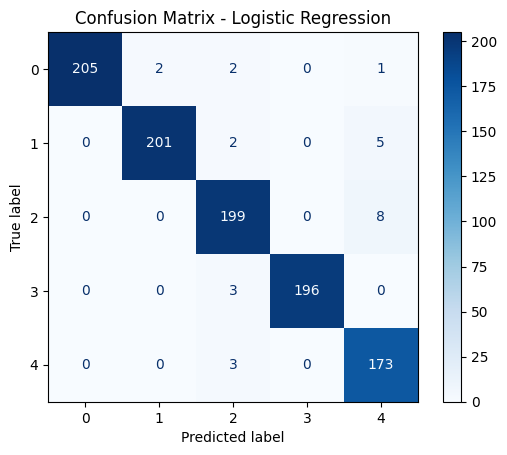

In [222]:
y_pred = best_model.predict(X_test_vec)
confusion_matrix = confusion_matrix(test_y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix, display_labels=best_model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [223]:
with open('../model/emotion_model.pkl', 'wb') as model_file:
    pickle.dump(best_model, model_file)

with open('../model/count_vectorizer.pkl', 'wb') as vectorizer_file:
    pickle.dump(vectorizer, vectorizer_file)